# Prerequisites
Importing libraries and datasets.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
from pathlib import Path
from datetime import date

from matplotlib.ticker import FuncFormatter
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
home_dir = Path.home()
print(home_dir)

/home/ibrahim


In [3]:
df1 = pd.read_csv(f"{home_dir}/git_repos/kubeflow-e2e/datasets/online+retail+ii/online_retail_II.csv")
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      525461 non-null  object 
 1   StockCode    525461 non-null  object 
 2   Description  522533 non-null  object 
 3   Quantity     525461 non-null  int64  
 4   InvoiceDate  525461 non-null  object 
 5   Price        525461 non-null  float64
 6   Customer ID  417534 non-null  float64
 7   Country      525461 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.1+ MB


In [4]:
df2 = pd.read_csv(f"{home_dir}/git_repos/kubeflow-e2e/datasets/online+retail/online-retail.csv")
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


# Data Preparation
Combining two separated datasets into a single dataset.

## Renaming columns

In [5]:
df1['UnitPrice'] = df1['Price']
df1['InvoiceNo'] = df1['Invoice']
df1['CustomerID'] = df1['Customer ID']
print(f'Columns: {df1.columns}')
df1 = df1.drop(columns=['Price', 'Invoice', 'Customer ID'])
print(f'Columns: {df1.columns}')

Columns: Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'UnitPrice', 'InvoiceNo',
       'CustomerID'],
      dtype='object')
Columns: Index(['StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Country',
       'UnitPrice', 'InvoiceNo', 'CustomerID'],
      dtype='object')


## Changing column type

In [6]:
df1['InvoiceDate'] = pd.to_datetime(df1['InvoiceDate'])
df2['InvoiceDate'] = pd.to_datetime(df2['InvoiceDate'])

## Setting merge point

In [7]:
print(f'End of First data: {df1['InvoiceDate'].max()}')
print(f'Start of Second data: {df2['InvoiceDate'].min()}')

End of First data: 2010-12-09 20:01:00
Start of Second data: 2010-12-01 08:26:00


In [8]:
print(df1['InvoiceDate'].nunique())
print(df2['InvoiceDate'].nunique())

25296
23260


In [9]:
df2 = df2[df2['InvoiceDate'] > df1['InvoiceDate'].max()]
print(df2['InvoiceDate'].nunique())

22339


## Merging data

In [10]:
df = pd.concat([df1, df2])
df = df.reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044847 entries, 0 to 1044846
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   StockCode    1044847 non-null  object        
 1   Description  1040572 non-null  object        
 2   Quantity     1044847 non-null  int64         
 3   InvoiceDate  1044847 non-null  datetime64[ns]
 4   Country      1044847 non-null  object        
 5   UnitPrice    1044847 non-null  float64       
 6   InvoiceNo    1044847 non-null  object        
 7   CustomerID   809560 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 63.8+ MB


In [11]:
df.info()
df.reset_index(drop=True).to_csv(f'{home_dir}/git_repos/kubeflow-e2e/datasets/online-retail-full.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044847 entries, 0 to 1044846
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   StockCode    1044847 non-null  object        
 1   Description  1040572 non-null  object        
 2   Quantity     1044847 non-null  int64         
 3   InvoiceDate  1044847 non-null  datetime64[ns]
 4   Country      1044847 non-null  object        
 5   UnitPrice    1044847 non-null  float64       
 6   InvoiceNo    1044847 non-null  object        
 7   CustomerID   809560 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 63.8+ MB


# Data Assessing, Cleaning and Transforming
Checking data reliability, handling missing values and outliers.

In [12]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,1044847.00,1044847,1044847.00,809560.00
mean,9.99,2011-01-03 11:43:47.797945856,4.59,15319.76
min,-80995.00,2009-12-01 07:45:00,-53594.36,12346.00
25%,1.00,2010-07-05 11:11:00,1.25,13969.00
50%,3.00,2010-12-08 16:34:00,2.10,15248.00
75%,10.00,2011-07-27 13:42:00,4.13,16792.00
max,80995.00,2011-12-09 12:50:00,38970.00,18287.00
std,174.22,NaN,121.70,1695.81


In [13]:
print(df.isna().sum())

StockCode           0
Description      4275
Quantity            0
InvoiceDate         0
Country             0
UnitPrice           0
InvoiceNo           0
CustomerID     235287
dtype: int64


## Assessing NULL values

Assessing data with NULL CustomerID. Are the transactions valid?

In [14]:
df_customer_isna = df[df['CustomerID'].isna() == True]
df_customer_isna.reset_index(drop=True).to_csv(f'{home_dir}/git_repos/kubeflow-e2e/datasets/online-retail-nan-customerid.csv', index=False)

Assessing data with NULL Description. Are the transactions valid?

In [15]:
df_desc_isna = df[df['Description'].isna() == True]
df_desc_isna.reset_index(drop=True).to_csv(f'{home_dir}/git_repos/kubeflow-e2e/datasets/online-retail-nan-desc.csv', index=False)

In [16]:
# df = df.dropna(subset='Description')
print(df.isna().sum())

StockCode           0
Description      4275
Quantity            0
InvoiceDate         0
Country             0
UnitPrice           0
InvoiceNo           0
CustomerID     235287
dtype: int64


## Datetime extraction
Extracting Year, Month, Week, Single Date, Normalized Date, Day of week and Day name from datetime column.

In [17]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Week'] = df['InvoiceDate'].dt.isocalendar().week.astype(int)
df['Date'] = df['InvoiceDate'].dt.day
df['NormDate'] = df['InvoiceDate'].dt.normalize()

# 0=monday, 6=sunday
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek
df['Day'] = df['InvoiceDate'].dt.day_name()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044847 entries, 0 to 1044846
Data columns (total 15 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   StockCode    1044847 non-null  object        
 1   Description  1040572 non-null  object        
 2   Quantity     1044847 non-null  int64         
 3   InvoiceDate  1044847 non-null  datetime64[ns]
 4   Country      1044847 non-null  object        
 5   UnitPrice    1044847 non-null  float64       
 6   InvoiceNo    1044847 non-null  object        
 7   CustomerID   809560 non-null   float64       
 8   Year         1044847 non-null  int32         
 9   Month        1044847 non-null  int32         
 10  Week         1044847 non-null  int64         
 11  Date         1044847 non-null  int32         
 12  NormDate     1044847 non-null  datetime64[ns]
 13  DayOfWeek    1044847 non-null  int32         
 14  Day          1044847 non-null  object        
dtypes: datetime64[n

In [18]:
df['Year'].unique()

array([2009, 2010, 2011], dtype=int32)

## Negative value (loss) handling

Some unit prices are invalid (zero or negative). To avoid invalid Sales value, these values are going to be deleted.

In [19]:
invalid_unitprice = df[df['UnitPrice'] <= 0]
print(f'Total rows with invalid unit price: {int(invalid_unitprice['UnitPrice'].count())}')
df = df[df['UnitPrice'] > 0]
print(f'Current minimal unit price value: {df['UnitPrice'].min()}')

Total rows with invalid unit price: 6029
Current minimal unit price value: 0.001


Creating Sales value. Some quantity values are negative, but it does not mean that they were invalid. They indicates losses.

In [20]:
df['Sales'] = df['Quantity'] * df['UnitPrice']

In [21]:
print(df[df['Sales'] <= 0]['InvoiceNo'].count())
df = df[df['Sales'] > 0]

19164


Calculating losses by summing both negative and positive quantities and sales in every transaction (single same invoice).

In [22]:
df_ui = df.groupby('InvoiceNo').agg(
    ItemSold = ('InvoiceNo', 'count'),
    NormDate = ('NormDate', 'min'),
    Year = ('Year', 'mean'),
    Month = ('Month', 'mean'),
    Week = ('Week', 'mean'),
    Date = ('Date', 'mean'),
    Quantity = ('Quantity', 'sum'),
    Sales = ('Sales', 'sum'),
    Country = ('Country', 'first')
).sort_values('InvoiceNo', ascending=True).reset_index()

df_ui['Year'] = df_ui['Year'].astype('int64')
df_ui['Month'] = df_ui['Month'].astype('int64')
df_ui['Week'] = df_ui['Week'].astype('int64')
df_ui['Date'] = df_ui['Date'].astype('int64')
df_ui.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40078 entries, 0 to 40077
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   InvoiceNo  40078 non-null  object        
 1   ItemSold   40078 non-null  int64         
 2   NormDate   40078 non-null  datetime64[ns]
 3   Year       40078 non-null  int64         
 4   Month      40078 non-null  int64         
 5   Week       40078 non-null  int64         
 6   Date       40078 non-null  int64         
 7   Quantity   40078 non-null  int64         
 8   Sales      40078 non-null  float64       
 9   Country    40078 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(6), object(2)
memory usage: 3.1+ MB


In [23]:
invalid_quantity = df_ui[df_ui['Quantity'] < 1]
print(f'Total rows with invalid quantity: {int(invalid_quantity['Quantity'].count())}')
df_ui = df_ui[df_ui['Quantity'] > 0]
print(f'Current minimal quantity value: {df_ui['Quantity'].min()}')

Total rows with invalid quantity: 0
Current minimal quantity value: 1


In [24]:
df_ui.count()

InvoiceNo    40078
ItemSold     40078
NormDate     40078
Year         40078
Month        40078
Week         40078
Date         40078
Quantity     40078
Sales        40078
Country      40078
dtype: int64

# Exploratory Analysis
Visualizing data, extracting insights and useful informations.

In [25]:
df_perday = df_ui.groupby('NormDate').agg(
    Invoices = ('InvoiceNo', 'count'),
    ItemSold = ('ItemSold', 'sum'),
    Year = ('Year', 'mean'),
    Month = ('Month', 'mean'),
    Week = ('Week', 'mean'),
    Date = ('Date', 'mean'),
    Quantity = ('Quantity', 'sum'),
    Sales = ('Sales', 'sum')
).sort_values('NormDate', ascending=True).reset_index()

df_perday['Year'] = df_perday['Year'].astype('int64')
df_perday['Month'] = df_perday['Month'].astype('int64')
df_perday['Week'] = df_perday['Week'].astype('int64')
df_perday['Date'] = df_perday['Date'].astype('int64')

df_perday['DayName'] = pd.to_datetime(df_perday['NormDate']).dt.day_name()
df_perday.head(30)

,NormDate,Invoices,ItemSold,Year,Month,Week,Date,Quantity,Sales,DayName
0,2009-12-01,119,3105,2009,12,49,1,26204,54513.50,Tuesday
1,2009-12-02,115,3250,2009,12,49,2,31896,63352.51,Wednesday
2,2009-12-03,124,2946,2009,12,49,3,49243,74037.91,Thursday
3,2009-12-04,89,2528,2009,12,49,4,21325,40732.92,Friday
4,2009-12-05,30,400,2009,12,49,5,5119,9803.05,Saturday
5,2009-12-06,74,1911,2009,12,49,6,11623,24613.64,Sunday
6,2009-12-07,101,2824,2009,12,50,7,18058,45083.35,Monday
7,2009-12-08,109,2189,2009,12,50,8,23159,49517.23,Tuesday
8,2009-12-09,88,2433,2009,12,50,9,17934,40616.09,Wednesday
9,2009-12-10,92,2403,2009,12,50,10,23718,44442.11,Thursday


## Single item sales
Each line in data represents a single sold item. There could be multiple items sold in a single invoice. Analyzing items sold in the data.

In [26]:
df2009 = df_perday[df_perday['Year'] == 2009]
df2010 = df_perday[df_perday['Year'] == 2010]
df2011 = df_perday[df_perday['Year'] == 2011]

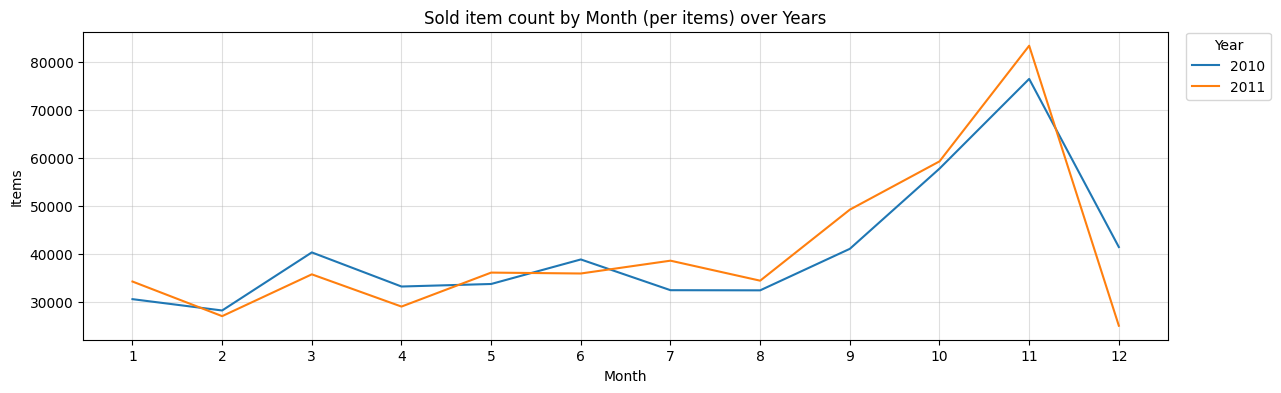

In [27]:
items_sum_2010 = df2010.groupby('Month').agg(
    y = ('ItemSold', 'sum')
).sort_values('Month', ascending=True).reset_index()

items_sum_2011 = df2011.groupby('Month').agg(
    y = ('ItemSold', 'sum')
).sort_values('Month', ascending=True).reset_index()

df_array = [items_sum_2010, items_sum_2011]
df_array_year = ['2010', '2011']

plt.figure(figsize=(14,4))
for i, data in enumerate(df_array):
    sns.lineplot(data=data, x='Month', y='y', label=f'{df_array_year[i]}')
plt.legend(title='Year', loc='upper left', bbox_to_anchor=(1.01, 1.02))
plt.title('Sold item count by Month (per items) over Years')
plt.grid(alpha=0.4)
plt.ylabel('Items')
plt.xticks(range(1,13,1))
plt.show()

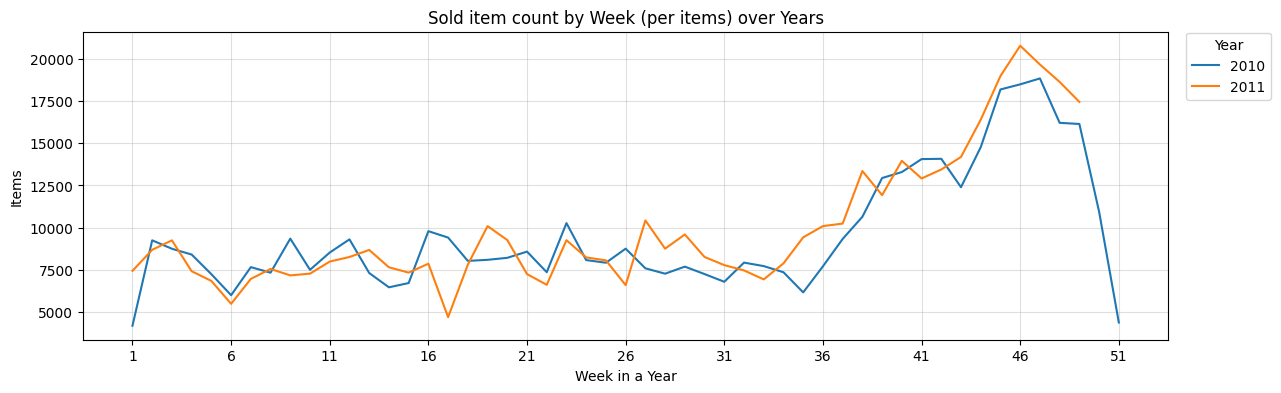

In [28]:
items_sum_2010 = df2010.groupby('Week').agg(
    y = ('ItemSold', 'sum')
).sort_values('Week', ascending=True).reset_index()

items_sum_2011 = df2011.groupby('Week').agg(
    y = ('ItemSold', 'sum')
).sort_values('Week', ascending=True).reset_index()

df_array = [items_sum_2010, items_sum_2011]
df_array_year = ['2010', '2011']

plt.figure(figsize=(14,4))
for i, data in enumerate(df_array):
    sns.lineplot(data=data, x='Week', y='y', label=f'{df_array_year[i]}')
plt.legend(title='Year', loc='upper left', bbox_to_anchor=(1.01, 1.02))
plt.title('Sold item count by Week (per items) over Years')
plt.ylabel('Items')
plt.grid(alpha=0.4)
plt.xlabel('Week in a Year')
plt.xticks(range(1, 55, 5))
plt.show()

## Quantity
Analyzing quantities sold.

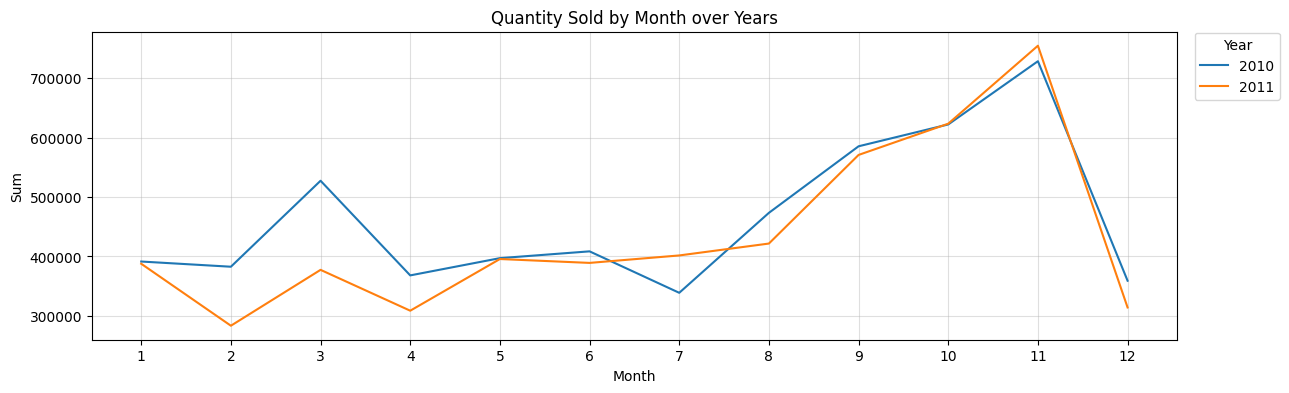

In [29]:
quantity_sum_2010 = df2010.groupby('Month').agg(
    y = ('Quantity', 'sum')
).sort_values('Month', ascending=True).reset_index()

quantity_sum_2011 = df2011.groupby('Month').agg(
    y = ('Quantity', 'sum')
).sort_values('Month', ascending=True).reset_index()

df_array = [quantity_sum_2010, quantity_sum_2011]
df_array_year = ['2010', '2011']

plt.figure(figsize=(14,4))
for i, data in enumerate(df_array):
    sns.lineplot(data=data, x='Month', y='y', label=f'{df_array_year[i]}')
plt.title('Quantity Sold by Month over Years')
plt.legend(title='Year', loc='upper left', bbox_to_anchor=(1.01, 1.02))
plt.grid(alpha=0.4)
plt.ylabel('Sum')
plt.xticks(range(1,13,1))
plt.show()

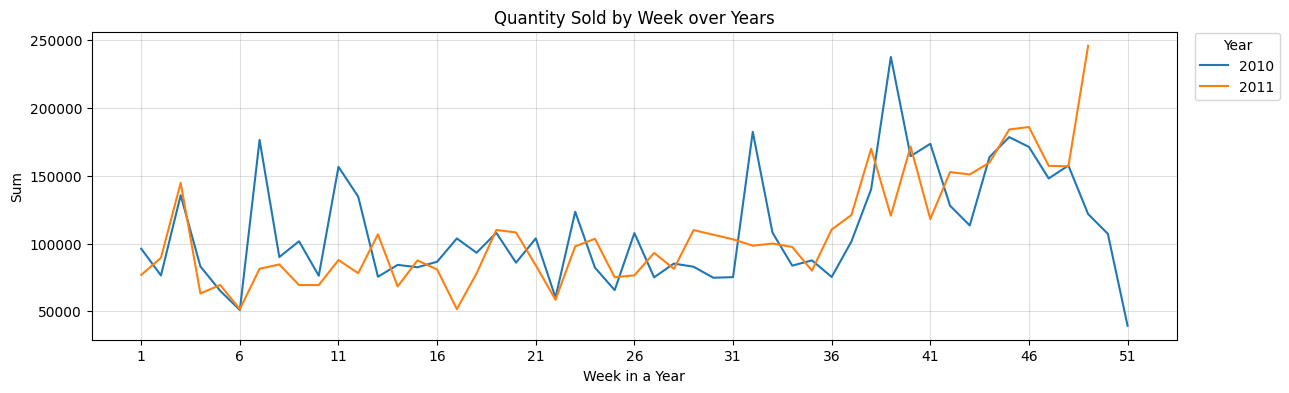

In [30]:
quantity_sum_2010 = df2010.groupby('Week').agg(
    y = ('Quantity', 'sum')
).sort_values('Week', ascending=True).reset_index()

quantity_sum_2011 = df2011.groupby('Week').agg(
    y = ('Quantity', 'sum')
).sort_values('Week', ascending=True).reset_index()

df_array = [quantity_sum_2010, quantity_sum_2011]
df_array_year = ['2010', '2011']

plt.figure(figsize=(14,4))
for i, data in enumerate(df_array):
    sns.lineplot(data=data, x='Week', y='y', label=f'{df_array_year[i]}')
plt.title('Quantity Sold by Week over Years')
plt.legend(title='Year', loc='upper left', bbox_to_anchor=(1.01, 1.02))
plt.grid(alpha=0.4)
plt.ylabel('Sum')
plt.xlabel('Week in a Year')
plt.xticks(range(1, 55, 5))
plt.show()

## Transactions
Analyzing transactions by identifying its unique value (InvoiceNo). Counting total and average of transactions.

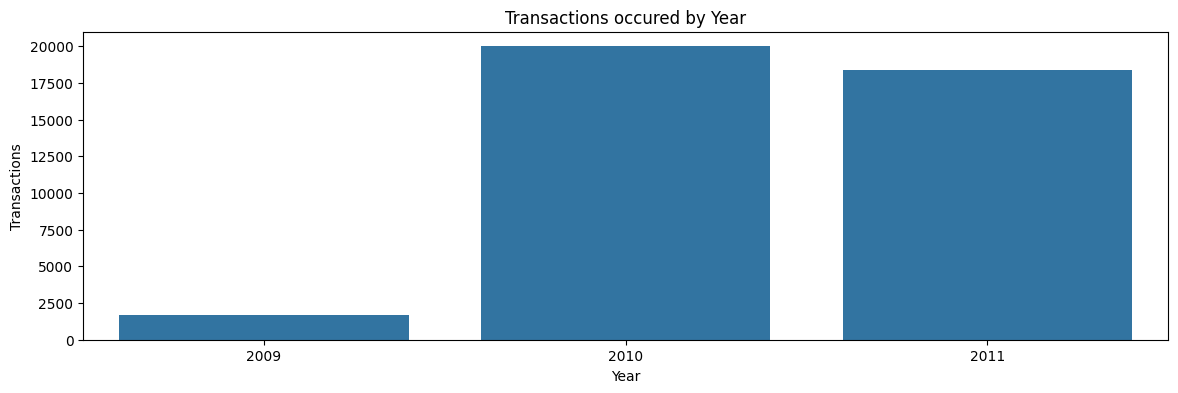

In [31]:
transactions_year_sum = df_perday.groupby('Year').agg(
    y = ('Invoices', 'sum')
).sort_values('Year', ascending=True).reset_index()

plt.figure(figsize=(14,4))
sns.barplot(data=transactions_year_sum, x='Year', y='y')
plt.title('Transactions occured by Year')
plt.ylabel('Transactions')
plt.xlabel('Year')
plt.show()

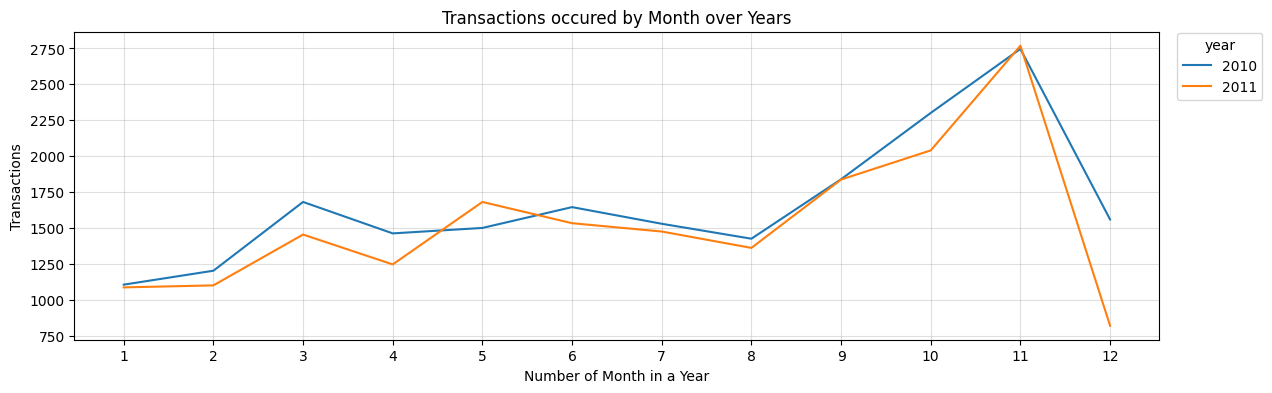

In [32]:
transactions_sum_2010 = df2010.groupby('Month').agg(
    y = ('Invoices', 'sum')
).sort_values('Month', ascending=True).reset_index()

transactions_sum_2011 = df2011.groupby('Month').agg(
    y = ('Invoices', 'sum')
).sort_values('Month', ascending=True).reset_index()

df_array = [transactions_sum_2010, transactions_sum_2011]
df_array_year = ['2010', '2011']

plt.figure(figsize=(14,4))
for i, data in enumerate(df_array):
    sns.lineplot(data=data, x='Month', y='y', label=f'{df_array_year[i]}')
plt.legend(title='year', loc='upper left', bbox_to_anchor=(1.01, 1.02))
plt.title('Transactions occured by Month over Years')
plt.ylabel('Transactions')
plt.xlabel('Number of Month in a Year')
plt.xticks(range(1,13,1))
plt.grid(alpha=0.4)
plt.show()

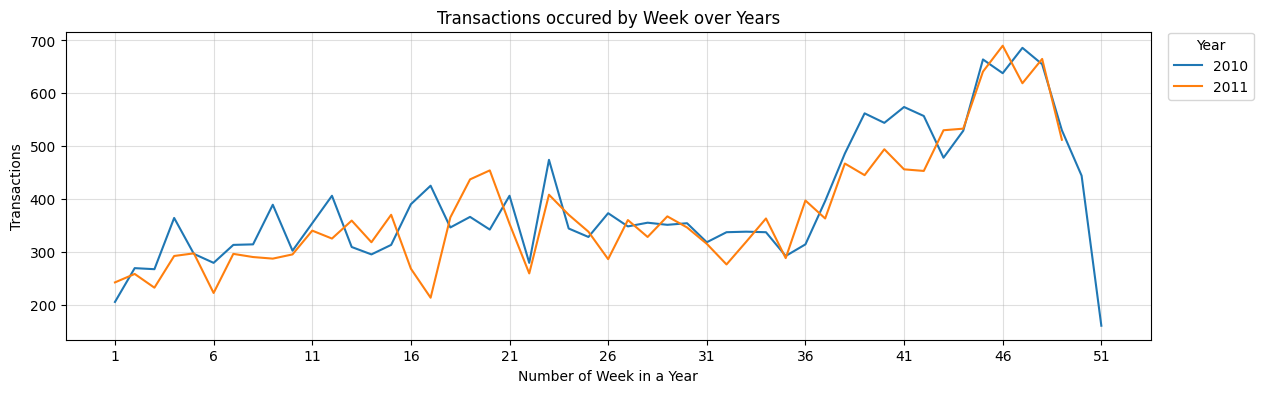

In [33]:
transactions_sum_2010 = df2010.groupby('Week').agg(
    y = ('Invoices', 'sum')
).sort_values('Week', ascending=True).reset_index()

transactions_sum_2011 = df2011.groupby('Week').agg(
    y = ('Invoices', 'sum')
).sort_values('Week', ascending=True).reset_index()

df_array = [transactions_sum_2010, transactions_sum_2011]
df_array_year = ['2010', '2011']

plt.figure(figsize=(14,4))
for i, data in enumerate(df_array):
    sns.lineplot(data=data, x='Week', y='y', label=f'{df_array_year[i]}')
plt.legend(title='Year', loc='upper left', bbox_to_anchor=(1.01, 1.02))
plt.title('Transactions occured by Week over Years')
plt.ylabel('Transactions')
plt.xlabel('Number of Week in a Year')
plt.xticks(range(1, 55, 5))
plt.grid(alpha=0.4)
plt.show()

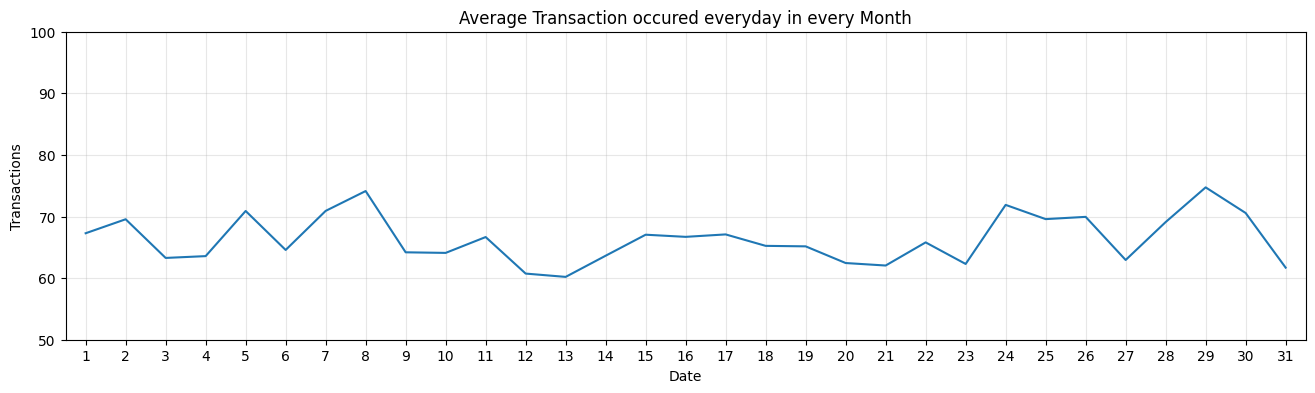

In [34]:
avg_df_counts = df_perday.groupby('Date')['Invoices'].mean().reset_index()

plt.figure(figsize=(16,4))
sns.lineplot(data=avg_df_counts, x='Date', y='Invoices')
plt.title('Average Transaction occured everyday in every Month')
plt.ylabel('Transactions')
plt.ylim(50,100)
plt.xlim(0.5,31.5)
plt.xticks(avg_df_counts['Date'].unique())
plt.grid(alpha=0.3)
plt.show()

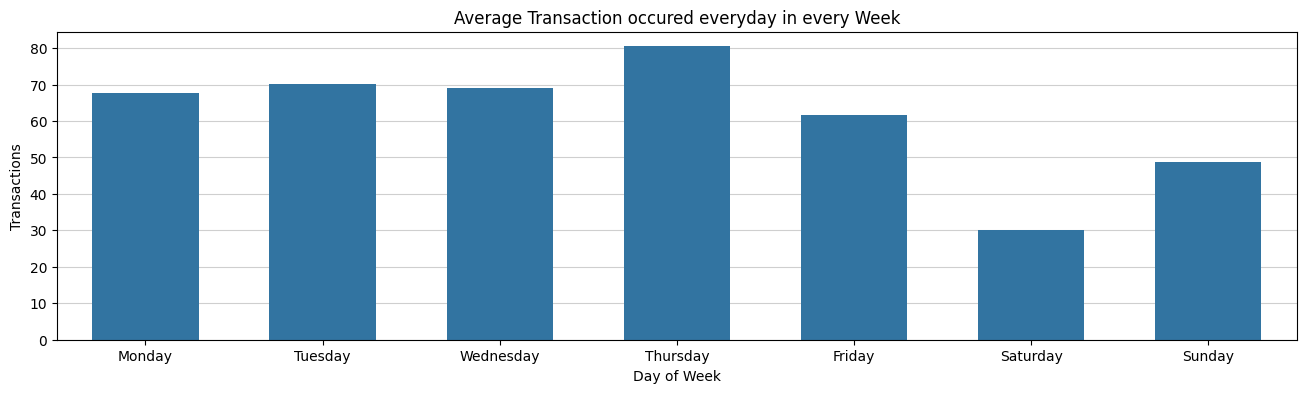

In [35]:
avg_df_counts = df_perday.groupby('DayName')['Invoices'].mean().reset_index()

days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
avg_df_counts['DayName'] = pd.Categorical(avg_df_counts['DayName'], categories=days, ordered=True)
avg_df_counts = avg_df_counts.sort_values('DayName')

plt.figure(figsize=(16,4))
sns.barplot(data=avg_df_counts, x='DayName', y='Invoices', zorder=2, width=0.6)
plt.title('Average Transaction occured everyday in every Week')
plt.ylabel('Transactions')
plt.xlabel('Day of Week')
plt.xticks(avg_df_counts['DayName'].unique())
plt.grid(alpha=0.6, axis='y', zorder=1)
plt.show()

## Sales
Sales are obtained from the total items sold. Unit price multiplied by quantity equals sales. Analying sales values.

In [36]:
def sterling_formatter(i, pos):
    if i >= 1e6:
        return f"£{i*1e-6:.1f} M"
    elif i >= 1e3:
        return f"£{i*1e-3:.1f} K"
    else:
        return f"£{i:.0f}"

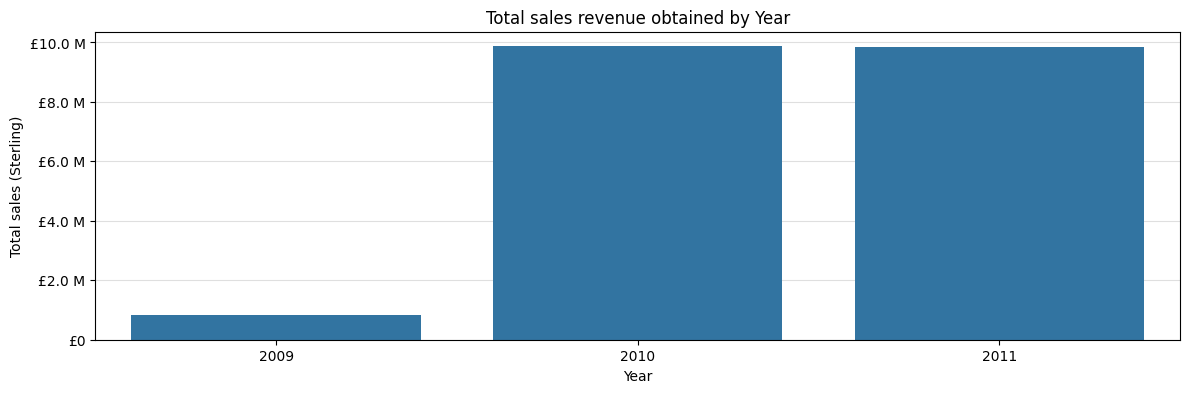

In [37]:
sales_year_sum = df_perday.groupby('Year').agg(
    y = ('Sales', 'sum')
).sort_values('Year', ascending=True).reset_index()

plt.figure(figsize=(14,4))
sns.barplot(data=sales_year_sum, x='Year', y='y', zorder=2)
plt.title('Total sales revenue obtained by Year')
plt.ylabel('Total sales (Sterling)')
plt.xlabel('Year')
plt.grid(axis='y', alpha=0.4, zorder=1)
plt.gca().yaxis.set_major_formatter(FuncFormatter(sterling_formatter))
plt.show()

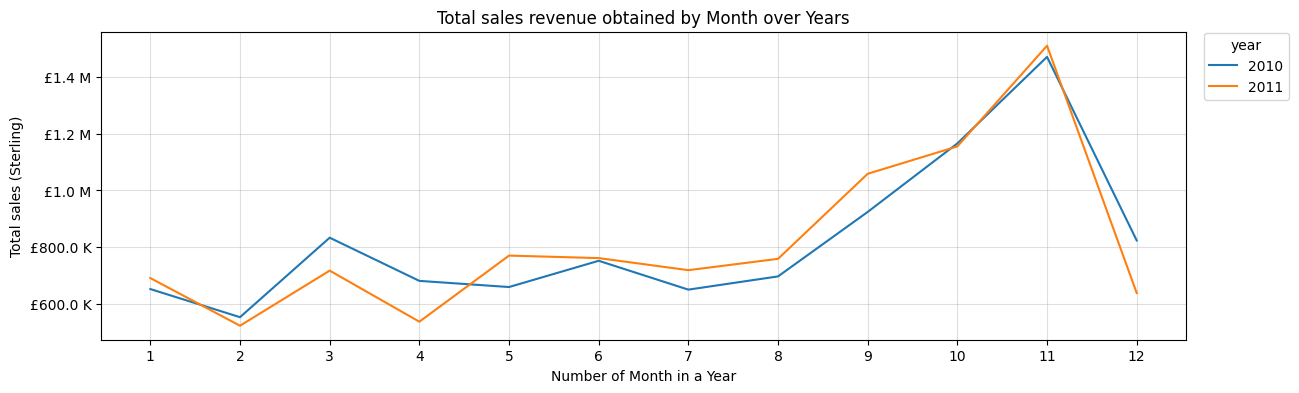

In [38]:
sales_sum_2010 = df2010.groupby('Month').agg(
    y = ('Sales', 'sum')
).sort_values('Month', ascending=True).reset_index()

sales_sum_2011 = df2011.groupby('Month').agg(
    y = ('Sales', 'sum')
).sort_values('Month', ascending=True).reset_index()

df_array = [sales_sum_2010, sales_sum_2011]
df_array_year = ['2010', '2011']

plt.figure(figsize=(14,4))
for i, data in enumerate(df_array):
    sns.lineplot(data=data, x='Month', y='y', label=f'{df_array_year[i]}')
plt.legend(title='year', loc='upper left', bbox_to_anchor=(1.01, 1.02))
plt.title('Total sales revenue obtained by Month over Years')
plt.ylabel('Total sales (Sterling)')
plt.xlabel('Number of Month in a Year')
plt.xticks(range(1,13,1))
plt.grid(alpha=0.4)
plt.gca().yaxis.set_major_formatter(FuncFormatter(sterling_formatter))
plt.show()

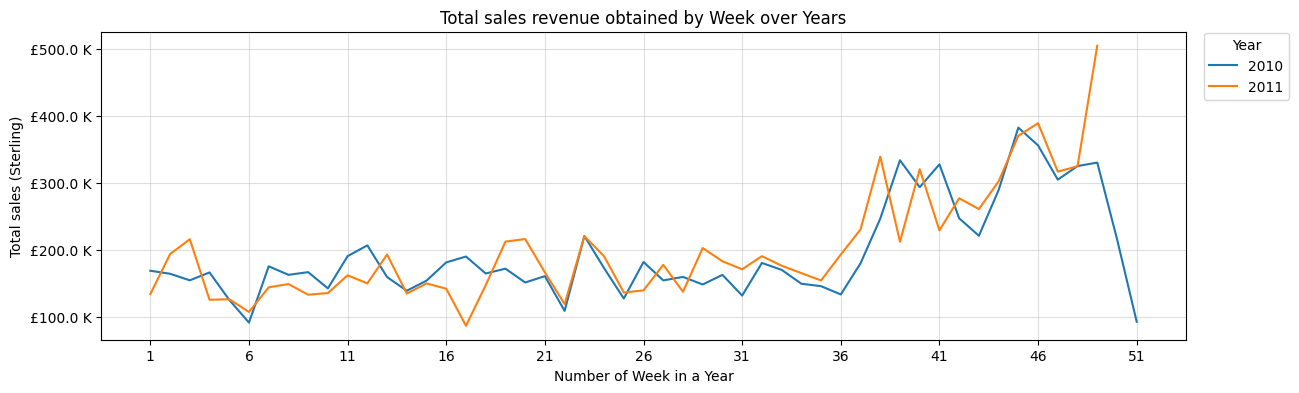

In [39]:
sales_sum_2010 = df2010.groupby('Week').agg(
    y = ('Sales', 'sum')
).sort_values('Week', ascending=True).reset_index()

sales_sum_2011 = df2011.groupby('Week').agg(
    y = ('Sales', 'sum')
).sort_values('Week', ascending=True).reset_index()

df_array = [sales_sum_2010, sales_sum_2011]
df_array_year = ['2010', '2011']

plt.figure(figsize=(14,4))
for i, data in enumerate(df_array):
    sns.lineplot(data=data, x='Week', y='y', label=f'{df_array_year[i]}')
plt.legend(title='Year', loc='upper left', bbox_to_anchor=(1.01, 1.02))
plt.title('Total sales revenue obtained by Week over Years')
plt.ylabel('Total sales (Sterling)')
plt.xlabel('Number of Week in a Year')
plt.xticks(range(1, 55, 5))
plt.gca().yaxis.set_major_formatter(FuncFormatter(sterling_formatter))
plt.grid(alpha=0.4)
plt.show()

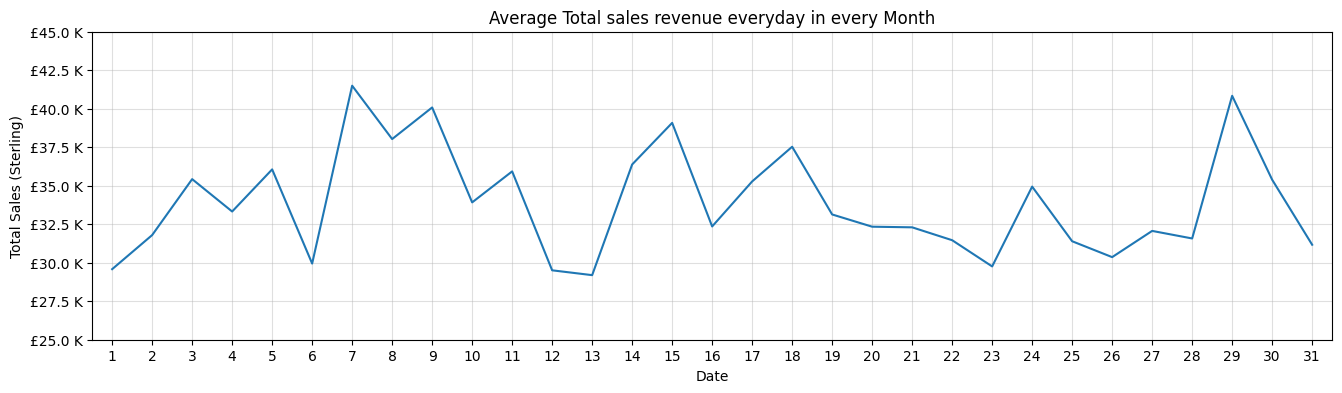

In [40]:
avg_sum_sales = df_perday.groupby('Date')['Sales'].mean().reset_index()

plt.figure(figsize=(16,4))
sns.lineplot(data=avg_sum_sales, x='Date', y='Sales')
plt.title('Average Total sales revenue everyday in every Month')
plt.ylabel('Total Sales (Sterling)')
plt.ylim(2.5*1e4,4.5*1e4)
plt.xlim(0.5,31.5)
plt.xticks(avg_sum_sales['Date'].unique())
plt.grid(alpha=0.4)
plt.gca().yaxis.set_major_formatter(FuncFormatter(sterling_formatter))
plt.show()

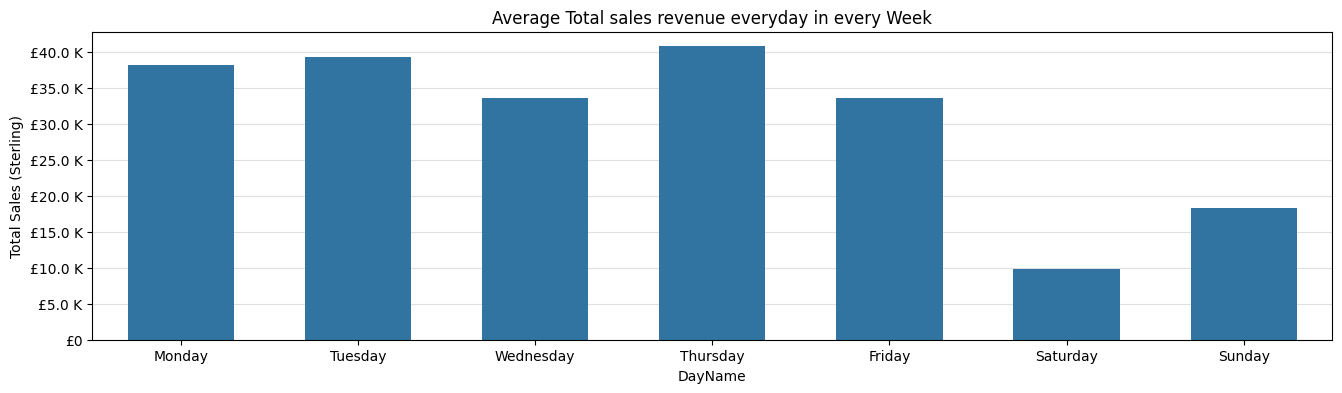

In [41]:
avg_sum_sales = df_perday.groupby('DayName')['Sales'].mean().reset_index()

days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
avg_sum_sales['DayName'] = pd.Categorical(avg_sum_sales['DayName'], categories=days, ordered=True)
avg_sum_sales = avg_sum_sales.sort_values('DayName')

plt.figure(figsize=(16,4))
sns.barplot(data=avg_sum_sales, x='DayName', y='Sales', zorder=2, width=0.6)
plt.title('Average Total sales revenue everyday in every Week')
plt.ylabel('Total Sales (Sterling)')
plt.xticks(avg_sum_sales['DayName'].unique())
plt.grid(alpha=0.4, axis='y', zorder=1)
plt.gca().yaxis.set_major_formatter(FuncFormatter(sterling_formatter))
plt.show()

# Feature Engineering
Creating new column as feature.

In [42]:
mod_df_perday = df_perday

## Seasonal Features
- Weekdays and Weekends
- End of Month
- Start of Month
- Four seasons (spring, summer, autumn, and winter)

In [43]:
mod_df_perday['DayNo'] = mod_df_perday['NormDate'].dt.dayofweek.astype(int)
mod_df_perday['IsMonthStart'] = mod_df_perday['NormDate'].dt.is_month_start.astype(int)
mod_df_perday['IsMonthEnd'] = mod_df_perday['NormDate'].dt.is_month_end.astype(int)

# 0 = spring, 1 = summer, 2 = autumn, 3 = winter
def get_season(month):
    if month in [3, 4, 5]:
        return 0
    elif month in [6, 7, 8]:
        return 1
    elif month in [9, 10, 11]:
        return 2
    else:
        return 3

mod_df_perday['Season'] = mod_df_perday['Month'].apply(get_season).astype(int)
mod_df_perday.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 604 entries, 0 to 603
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   NormDate      604 non-null    datetime64[ns]
 1   Invoices      604 non-null    int64         
 2   ItemSold      604 non-null    int64         
 3   Year          604 non-null    int64         
 4   Month         604 non-null    int64         
 5   Week          604 non-null    int64         
 6   Date          604 non-null    int64         
 7   Quantity      604 non-null    int64         
 8   Sales         604 non-null    float64       
 9   DayName       604 non-null    object        
 10  DayNo         604 non-null    int64         
 11  IsMonthStart  604 non-null    int64         
 12  IsMonthEnd    604 non-null    int64         
 13  Season        604 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(11), object(1)
memory usage: 66.2+ KB


## Aggregated Historical Features
- Lag Features (`lag_1`, `lag_7`, `lag_30`)
- Rolling Sum (7, 30)
- Rolling Mean (7, 30)
- Rolling Standards/Volatility (7, 30)
- Exponential Moving Average (EMA) (7)

### Quantity

In [44]:
# Lag_1, Lag_7, Lag_30
mod_df_perday['Qty_lag1'] = mod_df_perday['Quantity'].shift(1)
mod_df_perday['Qty_lag7'] = mod_df_perday['Quantity'].shift(7)
mod_df_perday['Qty_lag30'] = mod_df_perday['Quantity'].shift(30)

# RolSum_7, RolSum_30
mod_df_perday['Qty_RolSum7'] = mod_df_perday['Quantity'].rolling(7).sum()
mod_df_perday['Qty_RolSum30'] = mod_df_perday['Quantity'].rolling(30).sum()

# RolMean_7, RolMean_30
mod_df_perday['Qty_RolMean7'] = mod_df_perday['Quantity'].rolling(7).mean()
mod_df_perday['Qty_RolMean30'] = mod_df_perday['Quantity'].rolling(30).mean()

# RolStd_7, RolStd_30
mod_df_perday['Qty_RolStd7'] = mod_df_perday['Quantity'].rolling(7).std()
mod_df_perday['Qty_RolStd30'] = mod_df_perday['Quantity'].rolling(30).std()

# EMA_7
mod_df_perday['Qty_EMA7'] = mod_df_perday['Quantity'].rolling(7).std()

mod_df_perday.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 604 entries, 0 to 603
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   NormDate       604 non-null    datetime64[ns]
 1   Invoices       604 non-null    int64         
 2   ItemSold       604 non-null    int64         
 3   Year           604 non-null    int64         
 4   Month          604 non-null    int64         
 5   Week           604 non-null    int64         
 6   Date           604 non-null    int64         
 7   Quantity       604 non-null    int64         
 8   Sales          604 non-null    float64       
 9   DayName        604 non-null    object        
 10  DayNo          604 non-null    int64         
 11  IsMonthStart   604 non-null    int64         
 12  IsMonthEnd     604 non-null    int64         
 13  Season         604 non-null    int64         
 14  Qty_lag1       603 non-null    float64       
 15  Qty_lag7       597 non-

### Sales

In [45]:
# Lag_1, Lag_7, Lag_30
mod_df_perday['Sls_lag1'] = mod_df_perday['Sales'].shift(1)
mod_df_perday['Sls_lag7'] = mod_df_perday['Sales'].shift(7)
mod_df_perday['Sls_lag30'] = mod_df_perday['Sales'].shift(30)

# RolSum_7, RolSum_30
mod_df_perday['Sls_RolSum7'] = mod_df_perday['Sales'].rolling(7).sum()
mod_df_perday['Sls_RolSum30'] = mod_df_perday['Sales'].rolling(30).sum()

# RolMean_7, RolMean_30
mod_df_perday['Sls_RolMean7'] = mod_df_perday['Sales'].rolling(7).mean()
mod_df_perday['Sls_RolMean30'] = mod_df_perday['Sales'].rolling(30).mean()

# RolStd_7, RolStd_30
mod_df_perday['Sls_RolStd7'] = mod_df_perday['Sales'].rolling(7).std()
mod_df_perday['Sls_RolStd30'] = mod_df_perday['Sales'].rolling(30).std()

# EMA_7
mod_df_perday['Sls_EMA7'] = mod_df_perday['Sales'].rolling(7).std()

mod_df_perday.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 604 entries, 0 to 603
Data columns (total 34 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   NormDate       604 non-null    datetime64[ns]
 1   Invoices       604 non-null    int64         
 2   ItemSold       604 non-null    int64         
 3   Year           604 non-null    int64         
 4   Month          604 non-null    int64         
 5   Week           604 non-null    int64         
 6   Date           604 non-null    int64         
 7   Quantity       604 non-null    int64         
 8   Sales          604 non-null    float64       
 9   DayName        604 non-null    object        
 10  DayNo          604 non-null    int64         
 11  IsMonthStart   604 non-null    int64         
 12  IsMonthEnd     604 non-null    int64         
 13  Season         604 non-null    int64         
 14  Qty_lag1       603 non-null    float64       
 15  Qty_lag7       597 non-

In [46]:
mod_df_perday.dropna(inplace=True)
mod_df_perday.count()

NormDate         574
Invoices         574
ItemSold         574
Year             574
Month            574
Week             574
Date             574
Quantity         574
Sales            574
DayName          574
DayNo            574
IsMonthStart     574
IsMonthEnd       574
Season           574
Qty_lag1         574
Qty_lag7         574
Qty_lag30        574
Qty_RolSum7      574
Qty_RolSum30     574
Qty_RolMean7     574
Qty_RolMean30    574
Qty_RolStd7      574
Qty_RolStd30     574
Qty_EMA7         574
Sls_lag1         574
Sls_lag7         574
Sls_lag30        574
Sls_RolSum7      574
Sls_RolSum30     574
Sls_RolMean7     574
Sls_RolMean30    574
Sls_RolStd7      574
Sls_RolStd30     574
Sls_EMA7         574
dtype: int64

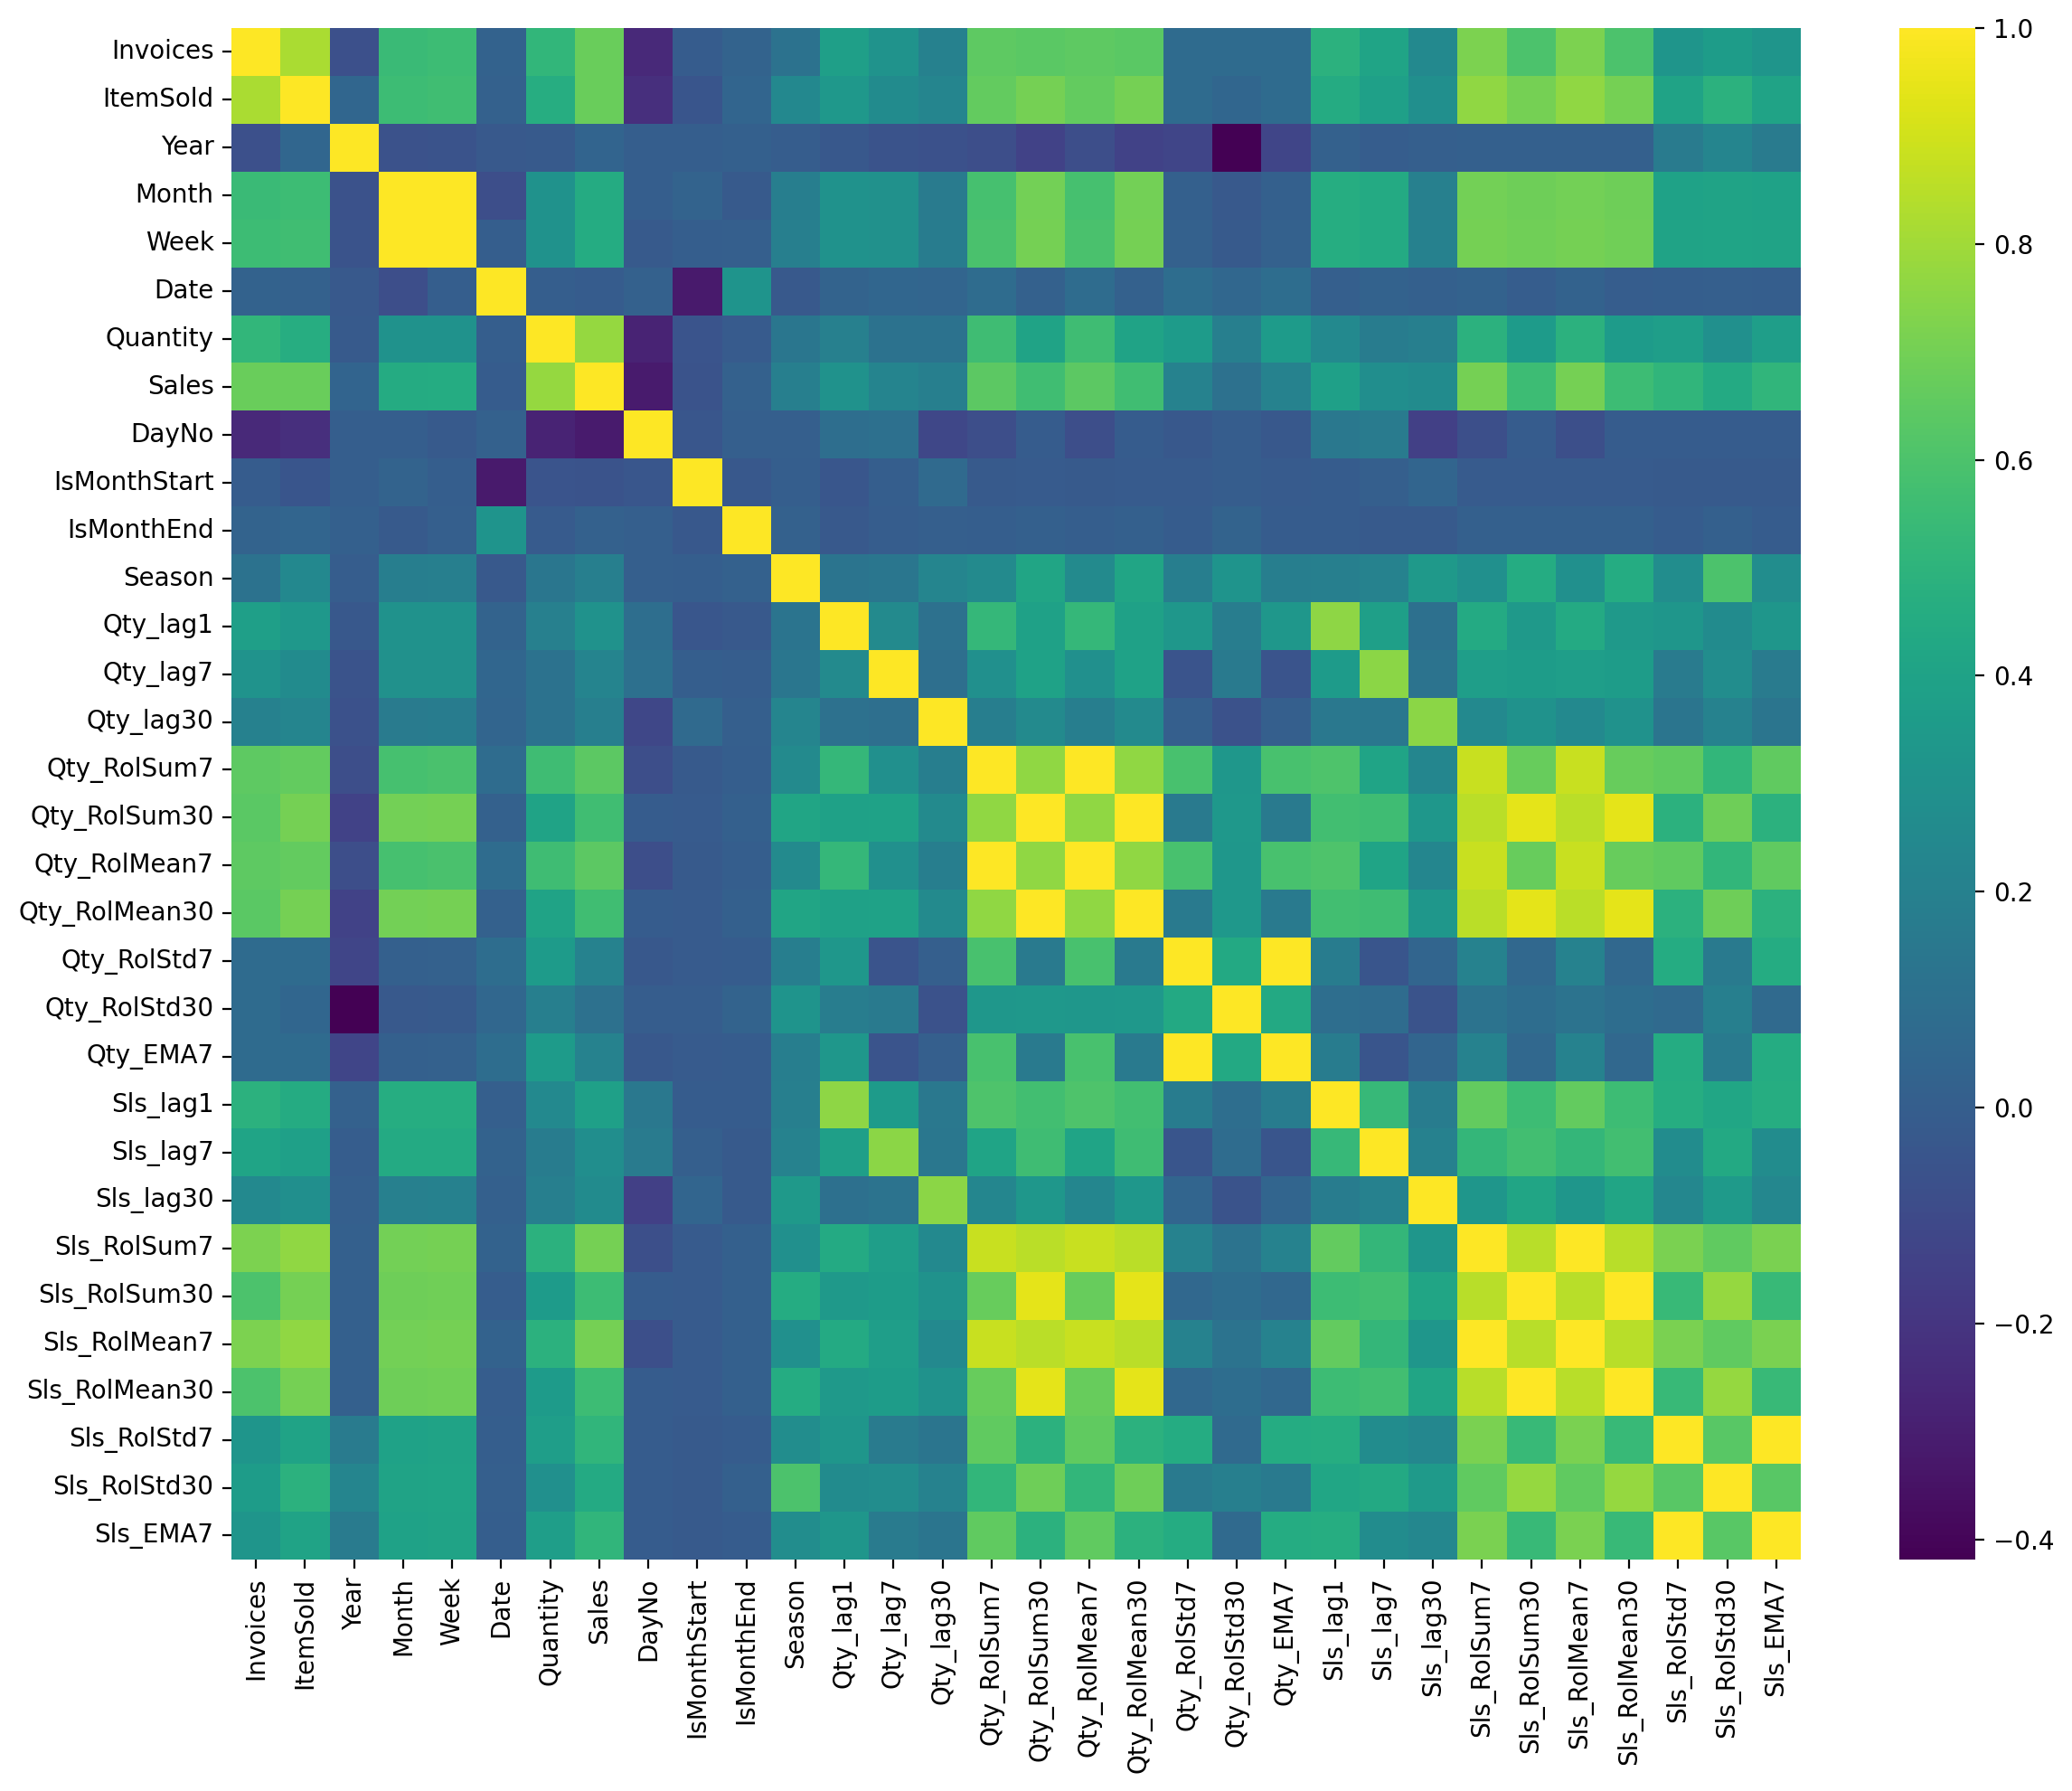

In [55]:
df_corr = mod_df_perday.corr(numeric_only=True)

plt.figure(dpi=200, figsize=(14,11))
sns.heatmap(annot=False, data=df_corr, cmap='viridis')
plt.show()

In [56]:
final_data_dir = f"{home_dir}/git_repos/kubeflow-e2e/datasets/final-data.csv"
mod_df_perday.to_csv(final_data_dir, index=False)
print(f"Final dataset successfully stored in {final_data_dir}. Happy training :)")

Final dataset successfully stored in /home/ibrahim/git_repos/kubeflow-e2e/datasets/final-data.csv. Happy training :)
